# Blackjack Monte Carlo Control

## 实验目标

本实验使用 `Monte Carlo Control` 求解 Blackjack，目标是让智能体逐步学会在不同点数组合下形成合理的要牌与停牌策略。这个实验的重点不是复杂模型，而是展示：在天然带回合边界的环境里，可以直接利用整局结束后的结果来反推哪些状态-动作选择更值得保留。


## 为什么这里选择 Monte Carlo Control

Blackjack 是最适合讲 `Monte Carlo Control` 的经典环境之一，原因很直接：

- 每局都有天然起点和终点
- 最终输赢会把整条决策轨迹的好坏一次性反映出来
- 状态空间有限，可以直接维护表格型动作价值
- 不需要像 `Q-Learning` 那样依赖一步一步的 bootstrapping 更新

因此，这里优先选择 `Monte Carlo Control`，是为了把“用完整回合回报反推策略”的方法主线讲清楚。


## 收敛判断方式

这个 notebook 不会笼统地说“训练结束”，而是通过几组具体信号判断策略是否已经稳定：

- 滚动平均回报是否逐步改善
- 滚动胜率是否显著高于随机基线
- `epsilon` 是否按预期逐步下降
- 最终策略图是否出现清晰的要牌/停牌边界
- 固定评估阶段的平均回报和胜率是否达到稳定水平

只有这些信号同时成立，才说明策略不是偶然赢几局，而是真的形成了可解释的决策边界。


## 设备与并行说明

- 本实验默认使用 `CPU`
- 不使用 `CUDA` 或 `MPS`
- 不启用并行环境

原因是本实验是典型表格强化学习任务，更新对象是状态-动作访问统计和平均回报，不需要神经网络或并行采样。


In [1]:
from collections import defaultdict
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm


In [2]:
ENV_ID = "Blackjack-v1"
NUM_EPISODES = 200000
EVAL_EPISODES = 5000
EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.99998
GAMMA = 1.0
ROLLING_WINDOW = 1000
SEED = 42

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

env = gym.make(ENV_ID)
q_values = defaultdict(lambda: np.zeros(env.action_space.n, dtype=np.float32))
returns_sum = defaultdict(float)
returns_count = defaultdict(int)


## 参数选择说明

这里的参数是按 Blackjack 这种回合式离散任务来配的，重点是让策略边界足够稳定：

- `NUM_EPISODES = 200000`：给 Monte Carlo 方法足够训练预算，减少回报方差带来的策略抖动
- `GAMMA = 1.0`：Blackjack 是标准回合结束型任务，完整保留最终回报最自然
- `EPSILON_START = 1.0`：训练初期充分探索
- `EPSILON_END = 0.05`：训练后期仍保留少量探索，避免边界过早僵化
- `EPSILON_DECAY = 0.99998`：让探索衰减更慢，使更多状态组合被反复访问
- `ROLLING_WINDOW = 1000`：Blackjack 单局很短，滚动窗口可以稍大一些，用来平滑观察趋势

如果训练后策略边界仍明显噪声较大，优先调整的方向通常是：

- 增加训练回合数
- 放慢 epsilon 衰减
- 提高评估回合数


In [3]:
def epsilon_greedy_action(q_table, state, epsilon, action_space):
    if np.random.random() < epsilon or state not in q_table:
        return action_space.sample()
    return int(np.argmax(q_table[state]))


def greedy_action(q_table, state):
    if state not in q_table:
        return 1
    return int(np.argmax(q_table[state]))


In [4]:
epsilon = EPSILON_START
episode_rewards = []
wins = []
draws = []
losses = []
epsilons = []

for episode in tqdm(range(NUM_EPISODES), desc="Monte Carlo episodes"):
    state, info = env.reset(seed=SEED + episode)
    trajectory = []
    done = False

    while not done:
        action = epsilon_greedy_action(q_values, state, epsilon, env.action_space)
        next_state, reward, terminated, truncated, info = env.step(action)
        trajectory.append((state, action, reward))
        state = next_state
        done = terminated or truncated

    G = 0.0
    visited = set()
    for t in reversed(range(len(trajectory))):
        state_t, action_t, reward_t = trajectory[t]
        G = GAMMA * G + reward_t
        key = (state_t, action_t)
        if key in visited:
            continue
        visited.add(key)
        returns_sum[key] += G
        returns_count[key] += 1
        q_values[state_t][action_t] = returns_sum[key] / returns_count[key]

    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)
    episode_rewards.append(float(reward))
    wins.append(int(reward > 0))
    draws.append(int(reward == 0))
    losses.append(int(reward < 0))
    epsilons.append(float(epsilon))

env.close()


Monte Carlo episodes:   0%|          | 0/200000 [00:00<?, ?it/s]

In [5]:
reward_series = pd.Series(episode_rewards)
win_series = pd.Series(wins)
epsilon_series = pd.Series(epsilons)

rolling_reward = reward_series.rolling(ROLLING_WINDOW).mean()
rolling_win_rate = win_series.rolling(ROLLING_WINDOW).mean()


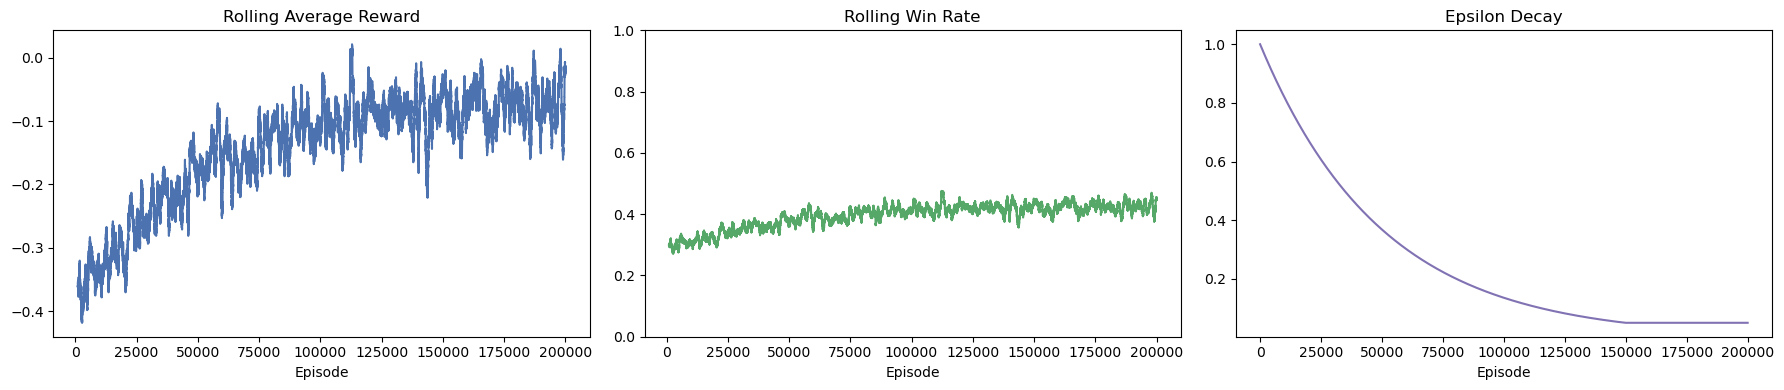

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(rolling_reward, color="#4c72b0")
axes[0].set_title("Rolling Average Reward")
axes[0].set_xlabel("Episode")

axes[1].plot(rolling_win_rate, color="#55a868")
axes[1].set_title("Rolling Win Rate")
axes[1].set_xlabel("Episode")
axes[1].set_ylim(0, 1)

axes[2].plot(epsilon_series, color="#8172b3")
axes[2].set_title("Epsilon Decay")
axes[2].set_xlabel("Episode")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "monte_carlo_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


In [7]:
def build_policy_and_value_maps(q_table, usable_ace):
    player_sums = np.arange(12, 22)
    dealer_cards = np.arange(1, 11)
    policy = np.zeros((len(player_sums), len(dealer_cards)), dtype=int)
    values = np.zeros((len(player_sums), len(dealer_cards)), dtype=float)

    for i, player_sum in enumerate(player_sums):
        for j, dealer_card in enumerate(dealer_cards):
            state = (int(player_sum), int(dealer_card), bool(usable_ace))
            action_values = q_table[state]
            policy[i, j] = int(np.argmax(action_values))
            values[i, j] = float(np.max(action_values))

    return player_sums, dealer_cards, policy, values


ps, dc, policy_no_ace, values_no_ace = build_policy_and_value_maps(q_values, usable_ace=False)
_, _, policy_usable_ace, values_usable_ace = build_policy_and_value_maps(q_values, usable_ace=True)


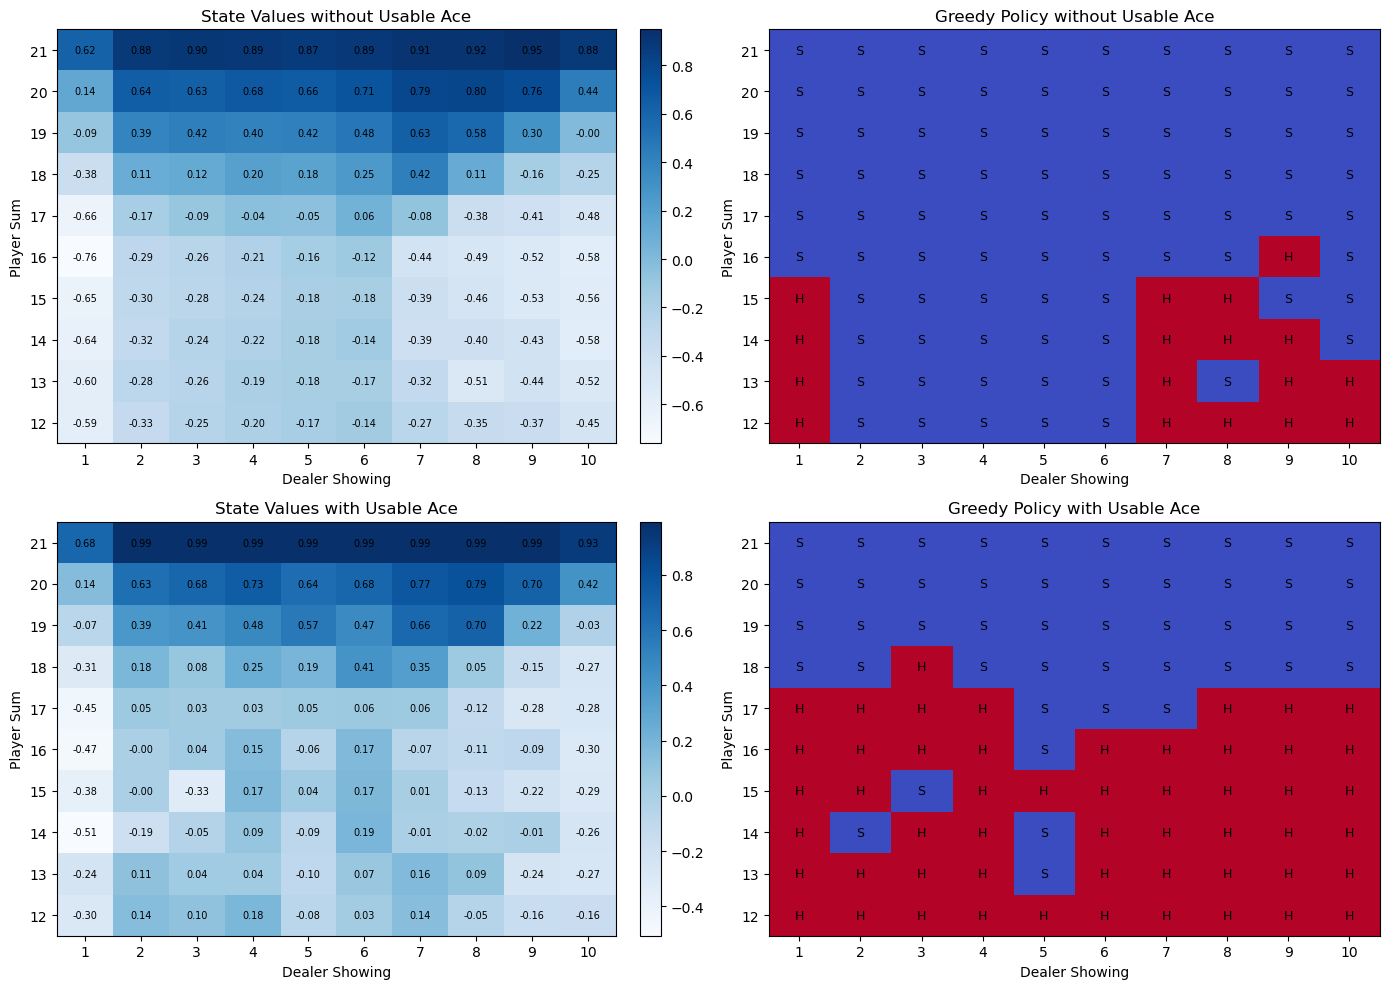

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

action_labels = {0: "stick", 1: "hit"}

im1 = axes[0, 0].imshow(values_no_ace, cmap="Blues", origin="lower", aspect="auto")
axes[0, 0].set_title("State Values without Usable Ace")
for i in range(values_no_ace.shape[0]):
    for j in range(values_no_ace.shape[1]):
        axes[0, 0].text(j, i, f"{values_no_ace[i, j]:.2f}", ha="center", va="center", color="black", fontsize=7)
fig.colorbar(im1, ax=axes[0, 0], fraction=0.046, pad=0.04)

axes[0, 1].imshow(policy_no_ace, cmap="coolwarm", origin="lower", aspect="auto", vmin=0, vmax=1)
axes[0, 1].set_title("Greedy Policy without Usable Ace")
for i in range(policy_no_ace.shape[0]):
    for j in range(policy_no_ace.shape[1]):
        axes[0, 1].text(j, i, "S" if policy_no_ace[i, j] == 0 else "H", ha="center", va="center", color="black", fontsize=9)

im2 = axes[1, 0].imshow(values_usable_ace, cmap="Blues", origin="lower", aspect="auto")
axes[1, 0].set_title("State Values with Usable Ace")
for i in range(values_usable_ace.shape[0]):
    for j in range(values_usable_ace.shape[1]):
        axes[1, 0].text(j, i, f"{values_usable_ace[i, j]:.2f}", ha="center", va="center", color="black", fontsize=7)
fig.colorbar(im2, ax=axes[1, 0], fraction=0.046, pad=0.04)

axes[1, 1].imshow(policy_usable_ace, cmap="coolwarm", origin="lower", aspect="auto", vmin=0, vmax=1)
axes[1, 1].set_title("Greedy Policy with Usable Ace")
for i in range(policy_usable_ace.shape[0]):
    for j in range(policy_usable_ace.shape[1]):
        axes[1, 1].text(j, i, "S" if policy_usable_ace[i, j] == 0 else "H", ha="center", va="center", color="black", fontsize=9)

for ax in axes.flat:
    ax.set_xticks(range(len(dc)))
    ax.set_xticklabels(dc)
    ax.set_yticks(range(len(ps)))
    ax.set_yticklabels(ps)
    ax.set_xlabel("Dealer Showing")
    ax.set_ylabel("Player Sum")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "monte_carlo_policy_visualization.png", dpi=150, bbox_inches="tight")
plt.show()


In [9]:
def evaluate_policy(q_table, env_id, episodes, seed_offset=500000):
    eval_env = gym.make(env_id)
    rewards = []
    wins = []
    draws = []
    losses = []

    for episode in range(episodes):
        state, info = eval_env.reset(seed=SEED + seed_offset + episode)
        done = False
        reward = 0.0

        while not done:
            action = greedy_action(q_table, state)
            next_state, reward, terminated, truncated, info = eval_env.step(action)
            state = next_state
            done = terminated or truncated

        rewards.append(float(reward))
        wins.append(int(reward > 0))
        draws.append(int(reward == 0))
        losses.append(int(reward < 0))

    eval_env.close()
    return {
        "average_reward": float(np.mean(rewards)),
        "win_rate": float(np.mean(wins)),
        "draw_rate": float(np.mean(draws)),
        "loss_rate": float(np.mean(losses)),
    }


eval_metrics = evaluate_policy(q_values, ENV_ID, EVAL_EPISODES)
eval_metrics


{'average_reward': -0.0568,
 'win_rate': 0.435,
 'draw_rate': 0.0732,
 'loss_rate': 0.4918}

In [10]:
metrics = pd.DataFrame(
    {
        "metric": [
            "training_win_rate",
            "training_draw_rate",
            "training_loss_rate",
            "training_average_reward",
            "final_epsilon",
            "eval_average_reward",
            "eval_win_rate",
            "eval_draw_rate",
            "eval_loss_rate",
        ],
        "value": [
            float(np.mean(wins)),
            float(np.mean(draws)),
            float(np.mean(losses)),
            float(np.mean(episode_rewards)),
            float(epsilon),
            float(eval_metrics["average_reward"]),
            float(eval_metrics["win_rate"]),
            float(eval_metrics["draw_rate"]),
            float(eval_metrics["loss_rate"]),
        ],
    }
)
metrics


,metric,value
0,training_win_rate,0.394615
1,training_draw_rate,0.067190
2,training_loss_rate,0.538195
3,training_average_reward,-0.143580
4,final_epsilon,0.050000
5,eval_average_reward,-0.056800
6,eval_win_rate,0.435000
7,eval_draw_rate,0.073200
8,eval_loss_rate,0.491800


In [11]:
policy_rows = []
for usable_ace, policy_map in [(0, policy_no_ace), (1, policy_usable_ace)]:
    for i, player_sum in enumerate(ps):
        for j, dealer_card in enumerate(dc):
            policy_rows.append(
                {
                    "usable_ace": usable_ace,
                    "player_sum": int(player_sum),
                    "dealer_showing": int(dealer_card),
                    "greedy_action": int(policy_map[i, j]),
                }
            )

value_rows = []
for usable_ace, value_map in [(0, values_no_ace), (1, values_usable_ace)]:
    for i, player_sum in enumerate(ps):
        for j, dealer_card in enumerate(dc):
            value_rows.append(
                {
                    "usable_ace": usable_ace,
                    "player_sum": int(player_sum),
                    "dealer_showing": int(dealer_card),
                    "state_value": float(value_map[i, j]),
                }
            )

metrics.to_csv(RESULTS_DIR / "monte_carlo_metrics.csv", index=False)
pd.DataFrame(policy_rows).to_csv(RESULTS_DIR / "monte_carlo_policy_table.csv", index=False)
pd.DataFrame(value_rows).to_csv(RESULTS_DIR / "monte_carlo_state_values.csv", index=False)
pd.DataFrame(
    {
        "reward": episode_rewards,
        "win": wins,
        "draw": draws,
        "loss": losses,
        "epsilon": epsilons,
    }
).to_csv(RESULTS_DIR / "monte_carlo_episode_summary.csv", index=False)

print(f"Training win rate: {np.mean(wins):.4f}")
print(f"Training average reward: {np.mean(episode_rewards):.4f}")
print(f"Final epsilon: {epsilon:.4f}")
print(f"Eval win rate: {eval_metrics['win_rate']:.4f}")
print(f"Eval average reward: {eval_metrics['average_reward']:.4f}")
print(f"Saved results to: {RESULTS_DIR.resolve()}")


Training win rate: 0.3946
Training average reward: -0.1436
Final epsilon: 0.0500
Eval win rate: 0.4350
Eval average reward: -0.0568
Saved results to: /Users/bizi/Desktop/GitHub/openai-gym-reinforcement-learning-lab/experiments/06-blackjack-monte-carlo-control/results


## 结果解读

训练完成后，重点观察以下内容：

- 滚动平均回报是否逐渐改善
- 胜率是否明显高于随机基线
- 最终策略图是否形成清晰的要牌/停牌边界
- usable ace 和 non-usable ace 两类状态下的策略是否出现结构性差异

如果这些现象都成立，就说明 `Monte Carlo Control` 已经在 Blackjack 里学到了可解释的策略形状。这个实验的核心价值在于，它把“整局结果如何反推单步决策”这条方法路线讲得非常直观。
